# Generate neural population activity data with quadstable attractor dynamics

##### Following Beiran et al., 2021, we generate quadstable attractor dynamics from a low-rank RNN with connectivity distributed as a mixture of four Gaussians.


### Load libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch

### Generative model for the connectivity distribution (mixture of four Gaussians)

##### Sample 1000 neurons from this distribution, with 250 samples from each Gaussian:

In [2]:
a_ms = [[-0.87, 0.87], [-0.87, -0.87], [0.87, -0.87], [0.87, 0.87]]
a_ns = [[-2.31, 2.31], [-2.31, -2.31], [2.31, -2.31], [2.31, 2.31]]
cov_true = [[0.25, 0, 0, 0], 
    [0, 0.25, 0, 0],
    [0, 0, 0.25, 0],
    [0, 0, 0, 0.25]]

c1 = np.random.multivariate_normal(mean=[-0.87, 0.87, -2.31, 2.31], cov=cov_true, size=250)
c2 = np.random.multivariate_normal(mean=[-0.87, -0.87, -2.31, -2.31], cov=cov_true, size=250)
c3 = np.random.multivariate_normal(mean=[0.87, -0.87, 2.31, -2.31], cov=cov_true, size=250)
c4 = np.random.multivariate_normal(mean=[0.87, 0.87, 2.31, 2.31], cov=cov_true, size=250)
data = np.concatenate((c1, c2, c3, c4), axis=0)

randinds = np.random.permutation(1000)
inv_perm = np.argsort(randinds)

M_true = data[randinds, :2]

##### Compute $\mathbb{E}[\boldsymbol{n}|\boldsymbol{m}]$ analytically:

In [3]:
def get_conditional_mean(m, a_ms, a_ns, cov_true):
    m = np.asarray(m)
    a_ms = np.asarray(a_ms)
    a_ns = np.asarray(a_ns)
    cov_true = np.asarray(cov_true)

    cov_xx = cov_true[:2, :2]
    cov_yx = cov_true[2:, :2]
    inv_cov_xx = np.linalg.inv(cov_xx)  # compute once

    # Precompute differences (shape: [n, 2])
    diff = a_ms - m

    # Compute Mahalanobis distances efficiently
    md2 = np.einsum('ij,jk,ik->i', diff, inv_cov_xx, diff)
    weights = np.exp(-0.5 * md2)
    weights /= np.sum(weights)  # normalize

    # Compute conditional means for each component
    cond_means = a_ns + (cov_yx @ inv_cov_xx @ diff.T).T  # shape: [n, 1 or d]

    # Weighted sum (conditional mean)
    mean_val = np.sum(weights[:, None] * cond_means, axis=0)
    return mean_val.squeeze()

In [4]:
enms = np.array([get_conditional_mean(M_true[i,:], a_ms, a_ns, cov_true) for i in range(M_true.shape[0])])
N_true = enms + np.random.normal(0, 1, enms.shape)

##### Generate latent trajectories from this low-rank RNN:

In [5]:
resolution = 20
x_, y_ = np.meshgrid(
    np.linspace(-2.4, 2.4, num=resolution), 
    np.linspace(-2.4, 2.4, num=resolution)
)

alpha = 0.1
latents = np.zeros((resolution*resolution, 100, 2))
for i in range(resolution):
    for j in range(resolution):
        xy = np.array([x_[i, j], y_[i, j]])
        for k in range(100):
            latents[i*resolution + j, k, :] = xy
            xy = xy + alpha * (-xy + np.tanh(xy @ M_true.T) @ N_true / N_true.shape[0])

##### Generate flow field from this low-rank RNN:

In [6]:
u_ = np.zeros_like(x_)
v_ = np.zeros_like(y_)
u_left_ = np.zeros_like(x_)
v_left_ = np.zeros_like(y_)
u_right_ = np.zeros_like(x_)
v_right_ = np.zeros_like(y_)
energy = np.zeros_like(x_)

for i in range(resolution):
    for j in range(resolution):
        xy = np.array([x_[i, j], y_[i, j]])
        uv_s = -xy + np.tanh(xy @ M_true.T) @ N_true / N_true.shape[0]
        u_[i, j] = uv_s[0]
        v_[i, j] = uv_s[1]

##### Plot the flow field and latent trajectories:

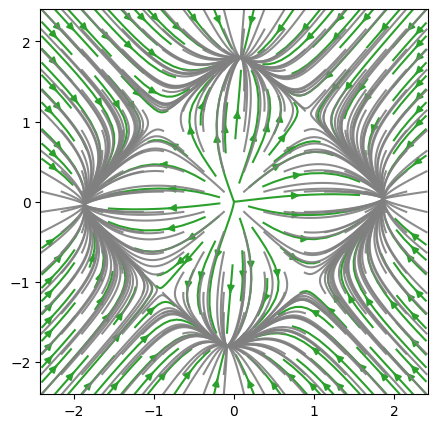

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.streamplot(x_, y_, u_, v_, color='#2ca02c')
plt.axis('equal')

for k in range(400):
    ax.plot(latents[k, :, 0], latents[k, :, 1], color='gray', alpha=0.9)

##### Save data:

In [ ]:
np.savez(
    '../data/quadstable_attractors.npz',
    latents = latents,
    MBD = M_true,
    N = N_true,
    potentials = latents @ M_true.T,
    rates = np.tanh(latents @ M_true.T),
    inv_perm = inv_perm,
    enms = enms
)     